<a href="https://colab.research.google.com/github/chrimapaul/Heart_Disease_Prediction_Group6/blob/main/Group6_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import seaborn as sns

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease.csv to heart_disease (1).csv


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

In [10]:
df=pd.read_csv('heart_disease.csv')

In [11]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [13]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [14]:
df.shape

(10000, 21)

data cleaning

missing values

In [15]:
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.inspection import permutation_importance

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [16]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage Missing": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing)

,Missing Values,Percentage Missing
Alcohol Consumption,2586,25.86
Diabetes,30,0.30
Sugar Consumption,30,0.30
Cholesterol Level,30,0.30
Age,29,0.29
Triglyceride Level,26,0.26
CRP Level,26,0.26
High LDL Cholesterol,26,0.26
High Blood Pressure,26,0.26
Low HDL Cholesterol,25,0.25


In [17]:
print(df["Heart Disease Status"].value_counts())

print("\nPercentage distribution:")
print(
    df["Heart Disease Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Percentage distribution:
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


checking target distribution

In [18]:
print(df["Heart Disease Status"].value_counts())

print("\nPercentage distribution:")
print(
    df["Heart Disease Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Percentage distribution:
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


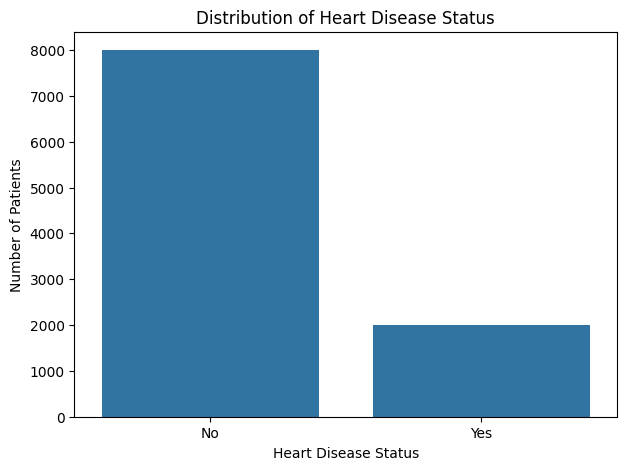

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Heart Disease Status"
)

plt.title("Distribution of Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")

plt.show()

Separating features and target

In [20]:
TARGET = "Heart Disease Status"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nTarget classes:")
print(y.unique())

Features: (10000, 20)
Target: (10000,)

Target classes:
['No' 'Yes']


Converting the target to binary

In [21]:
y = y.map({
    "No": 0,
    "Yes": 1
})

print(y.value_counts())

Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64


Identify numerical and categorical columns

In [22]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

Categorical features:
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

Number of numerical features: 9
Number of categorical features: 11


training and splitting

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (8000, 20)
Testing set: (2000, 20)

Training target distribution:
Heart Disease Status
0    0.8
1    0.2
Name: proportion, dtype: float64

Testing target distribution:
Heart Disease Status
0    0.8
1    0.2
Name: proportion, dtype: float64


Create leakage-safe preprocessing

In [24]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Leakage-safe preprocessing pipeline created.")

Leakage-safe preprocessing pipeline created.


Baseline model

In [25]:
from sklearn.dummy import DummyClassifier

baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline Accuracy:",
      accuracy_score(y_test, baseline_pred))

print("\nBaseline Classification Report:")
print(
    classification_report(
        y_test,
        baseline_pred,
        target_names=["No Disease", "Disease"]
    )
)

Baseline Accuracy: 0.8

Baseline Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89      1600
     Disease       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



Model 1: Logistic Regression

In [26]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION")
print("=" * 50)

print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=["No Disease", "Disease"]
    )
)

print("ROC-AUC:",
      roc_auc_score(y_test, logistic_prob))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89      1600
     Disease       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

ROC-AUC: 0.48630312499999995


Model 2: Decision Tree

In [27]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=6,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]

print("DECISION TREE")
print("=" * 50)

print(
    classification_report(
        y_test,
        tree_pred,
        target_names=["No Disease", "Disease"]
    )
)

print("ROC-AUC:",
      roc_auc_score(y_test, tree_prob))

DECISION TREE
              precision    recall  f1-score   support

  No Disease       0.80      0.99      0.88      1600
     Disease       0.29      0.02      0.04       400

    accuracy                           0.79      2000
   macro avg       0.55      0.50      0.46      2000
weighted avg       0.70      0.79      0.72      2000

ROC-AUC: 0.517125
